In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Clustering Models
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, roc_curve, mean_absolute_error, mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

# ***EDA***

In [ ]:
df = pd.read_csv('customer_360_ml_workshop.csv')
df.head(10)

,CustomerID,Age,Region,TenureMonths,ContractType,InternetType,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,PaperlessBilling,AutoPay,SatisfactionScore,Future12MRevenueEGP,Churn
0,CUST-00001,22,Alexandria,23,Month-to-month,DSL,317.9,580.48,5,5,0,Yes,Yes,5.0,6287.08,Yes
1,CUST-00002,59,Upper Egypt,9,Month-to-month,4G/5G,359.3,434.36,1,1,1,No,Yes,4.0,4619.91,No
2,CUST-00003,52,Giza,21,Month-to-month,DSL,176.9,391.35,3,5,1,Yes,Yes,5.0,4512.25,No
3,CUST-00004,41,Giza,12,Month-to-month,DSL,312.5,420.40,3,2,1,No,Yes,5.0,3809.65,No
4,CUST-00005,40,Delta,21,Month-to-month,4G/5G,191.6,462.73,3,4,0,No,Yes,3.0,4731.09,No
5,CUST-00006,63,Giza,14,One year,4G/5G,283.6,444.27,3,2,0,No,Yes,4.0,5089.90,No
6,CUST-00007,22,Delta,21,Month-to-month,Fiber,348.0,420.33,1,2,3,Yes,Yes,2.0,3920.17,Yes
7,CUST-00008,54,Giza,54,One year,Fiber,158.5,440.98,4,2,0,Yes,No,3.0,6792.27,No
8,CUST-00009,28,Cairo,37,Two year,DSL,63.0,247.01,1,3,0,Yes,Yes,4.0,3994.31,No
9,CUST-00010,22,Delta,19,One year,4G/5G,396.3,354.51,1,0,1,Yes,No,4.0,3973.85,No


In [ ]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (3000, 16)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           3000 non-null   object 
 1   Age                  3000 non-null   int64  
 2   Region               3000 non-null   object 
 3   TenureMonths         3000 non-null   int64  
 4   ContractType         3000 non-null   object 
 5   InternetType         2955 non-null   object 
 6   MonthlyUsageGB       2925 non-null   float64
 7   MonthlyChargeEGP     3000 non-null   float64
 8   NumServices          3000 non-null   int64  
 9   SupportCalls6M       3000 non-null   int64  
 10  LatePayments12M      3000 non-null   int64  
 11  PaperlessBilling     3000 non-null   object 
 12  AutoPay              3000 non-null   object 
 13  SatisfactionScore    2940 non-null   float64
 14  Future12MRevenueEGP  3000 non-null   flo

In [ ]:
print("\nDescriptive Statistics:")
display(df.describe())

print("\nMissing Values:")
display(df.isnull().sum())


Descriptive Statistics:


,Age,TenureMonths,MonthlyUsageGB,MonthlyChargeEGP,NumServices,SupportCalls6M,LatePayments12M,SatisfactionScore,Future12MRevenueEGP
count,3000.000000,3000.000000,2925.000000,3000.000000,3000.000000,3000.000000,3000.000000,2940.000000,3000.000000
mean,44.057667,25.540667,230.132855,487.345707,3.515000,2.206333,1.111000,3.486054,5361.156050
std,15.346319,16.525739,89.357331,118.451753,1.714085,1.503722,1.066016,1.013758,1479.868751
min,18.000000,1.000000,10.000000,142.400000,1.000000,0.000000,0.000000,1.000000,1529.370000
25%,31.000000,13.000000,169.500000,398.992500,2.000000,1.000000,0.000000,3.000000,4330.792500
50%,44.000000,22.000000,228.700000,484.995000,4.000000,2.000000,1.000000,4.000000,5274.620000
75%,57.000000,35.000000,290.400000,574.572500,5.000000,3.000000,2.000000,4.000000,6314.497500
max,70.000000,72.000000,597.900000,866.990000,6.000000,9.000000,6.000000,5.000000,11095.190000



Missing Values:


,0
CustomerID,0
Age,0
Region,0
TenureMonths,0
ContractType,0
InternetType,45
MonthlyUsageGB,75
MonthlyChargeEGP,0
NumServices,0
SupportCalls6M,0


In [ ]:
# Convert 'Yes'/'No' to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [ ]:
X_churn = df.drop(columns=['Churn', 'Future12MRevenueEGP'])
y_churn = df['Churn']

X_revenue = df.drop(columns=['Future12MRevenueEGP'])
y_revenue = df['Future12MRevenueEGP']

In [ ]:
num_cols = X_churn.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_churn.select_dtypes(include=['object', 'category']).columns.tolist()

In [ ]:
# Train/Test Split (Stratified for Churn)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

# Train/Test Split for Revenue
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_revenue, y_revenue, test_size=0.2, random_state=42)

# ***Data Preprocessing Pipeline***

In [ ]:
num_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

cat_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)])

# ***Churn Classification***

In [ ]:
classifiers = {
    # Added class_weight='balanced'
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'KNN': KNeighborsClassifier(), # KNN doesn't support class_weight directly
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42) # Gradient Boosting in sklearn doesn't support class_weight
}

print("--- Classification Results ---")
for name, clf in classifiers.items():
    # Build pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    # We use a dense converter if Naive Bayes fails with sparse matrix from OHE
    if name == 'Naive Bayes':
        pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('to_dense', StandardScaler(with_mean=False)), # dummy step to fit dense
                                   ('classifier', clf)])
        X_train_c_dense = preprocessor.fit_transform(X_train_c).toarray()
        X_test_c_dense = preprocessor.transform(X_test_c).toarray()
        clf.fit(X_train_c_dense, y_train_c)
        y_pred = clf.predict(X_test_c_dense)
        y_prob = clf.predict_proba(X_test_c_dense)[:, 1]
    else:
        pipeline.fit(X_train_c, y_train_c)
        y_pred = pipeline.predict(X_test_c)
        y_prob = pipeline.predict_proba(X_test_c)[:, 1]

    print(f"\n{name}:")
    print(f"Accuracy:  {accuracy_score(y_test_c, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_c, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test_c, y_pred):.4f}")
    print(f"F1 Score:  {f1_score(y_test_c, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test_c, y_prob):.4f}")

--- Classification Results ---

Logistic Regression:
Accuracy:  0.7333
Precision: 0.3591
Recall:    0.5963
F1 Score:  0.4483
ROC-AUC:   0.7601

KNN:
Accuracy:  0.7917
Precision: 0.3400
Recall:    0.1560
F1 Score:  0.2138
ROC-AUC:   0.5973

Decision Tree:
Accuracy:  0.7183
Precision: 0.2692
Recall:    0.3211
F1 Score:  0.2929
ROC-AUC:   0.5638

Random Forest:
Accuracy:  0.8217
Precision: 0.6667
Recall:    0.0367
F1 Score:  0.0696
ROC-AUC:   0.7142

SVM:
Accuracy:  0.7083
Precision: 0.3382
Recall:    0.6330
F1 Score:  0.4409
ROC-AUC:   0.7450

Naive Bayes:
Accuracy:  0.1817
Precision: 0.1817
Recall:    1.0000
F1 Score:  0.3075
ROC-AUC:   0.5000

Gradient Boosting:
Accuracy:  0.8133
Precision: 0.4400
Recall:    0.1009
F1 Score:  0.1642
ROC-AUC:   0.7418


In [ ]:
# Hyperparameter Tuning for Random Forest
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('rf', RandomForestClassifier(random_state=42))])
param_grid = {
    'rf__n_estimators': [100, 300],
    'rf__max_depth': [5, 10, None],
    'rf__min_samples_leaf': [1, 5, 10],
    'rf__class_weight': [None, 'balanced', 'balanced_subsample'],
}
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='roc_auc')
grid_search.fit(X_train_c, y_train_c)
best_rf = grid_search.best_estimator_

print(f"Best RF Params: {grid_search.best_params_}")

Best RF Params: {'rf__class_weight': None, 'rf__max_depth': 10, 'rf__min_samples_leaf': 1, 'rf__n_estimators': 100}


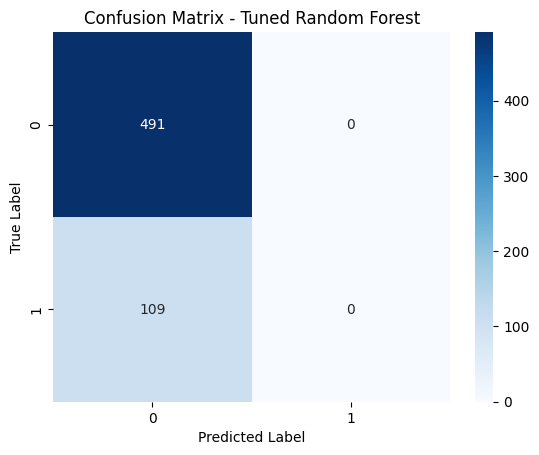

In [ ]:
y_pred_best = best_rf.predict(X_test_c)
cm = confusion_matrix(y_test_c, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

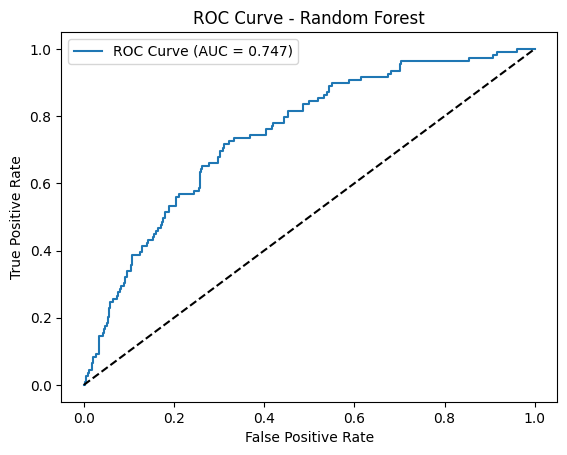

In [ ]:
# Plot ROC Curve
y_prob_best = best_rf.predict_proba(X_test_c)[:, 1]
fpr, tpr, _ = roc_curve(y_test_c, y_prob_best)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_score(y_test_c, y_prob_best):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ***Revenue Regression***

In [ ]:
regressors = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Need a preprocessor for regression that includes 'Churn' as a feature if desired
num_cols_r = X_revenue.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols_r = X_revenue.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_r = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols_r),
        ('cat', cat_transformer, cat_cols_r)
    ])

print("--- Regression Results ---")
best_reg_name = None
best_r2 = -float('inf')
best_reg_model = None

for name, reg in regressors.items():
    pipeline_r = Pipeline(steps=[('preprocessor', preprocessor_r), ('regressor', reg)])
    pipeline_r.fit(X_train_r, y_train_r)
    y_pred_r = pipeline_r.predict(X_test_r)

    r2 = r2_score(y_test_r, y_pred_r)
    print(f"\n{name}:")
    print(f"MAE:  {mean_absolute_error(y_test_r, y_pred_r):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}")
    print(f"R2:   {r2:.4f}")

    if r2 > best_r2:
        best_r2 = r2
        best_reg_name = name
        best_reg_model = pipeline_r

--- Regression Results ---

Linear Regression:
MAE:  378.35
RMSE: 474.83
R2:   0.8924

Ridge:
MAE:  378.34
RMSE: 474.81
R2:   0.8924

Lasso:
MAE:  378.62
RMSE: 475.00
R2:   0.8923

KNN Regressor:
MAE:  615.05
RMSE: 784.29
R2:   0.7064

Decision Tree:
MAE:  509.32
RMSE: 648.04
R2:   0.7996

Random Forest:
MAE:  386.78
RMSE: 489.99
R2:   0.8854

Gradient Boosting:
MAE:  370.23
RMSE: 468.15
R2:   0.8954


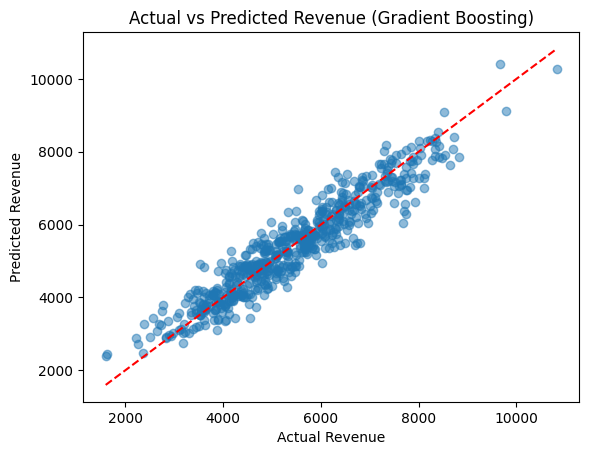

In [ ]:
y_pred_best_r = best_reg_model.predict(X_test_r)
plt.scatter(y_test_r, y_pred_best_r, alpha=0.5)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.title(f"Actual vs Predicted Revenue ({best_reg_name})")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.show()

## ***Customer Segmentation***

In [ ]:
seg_features = ['TenureMonths', 'MonthlyUsageGB', 'MonthlyChargeEGP',
                'NumServices', 'SupportCalls6M', 'LatePayments12M', 'SatisfactionScore']

df_seg = df[seg_features].fillna(df[seg_features].median())
scaler = StandardScaler()
X_seg_scaled = scaler.fit_transform(df_seg)

# K-Means Evaluation
inertia = []
sil_scores = []
k_range = range(2, 8)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_seg_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_seg_scaled, clusters))

# Select K based on silhouette/elbow
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
df['KMeans_Segment'] = kmeans_final.fit_predict(X_seg_scaled)

# DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Labels'] = dbscan.fit_predict(X_seg_scaled)

## ***PCA***

PCA Explained Variance Ratio: [0.262416  0.1495416]



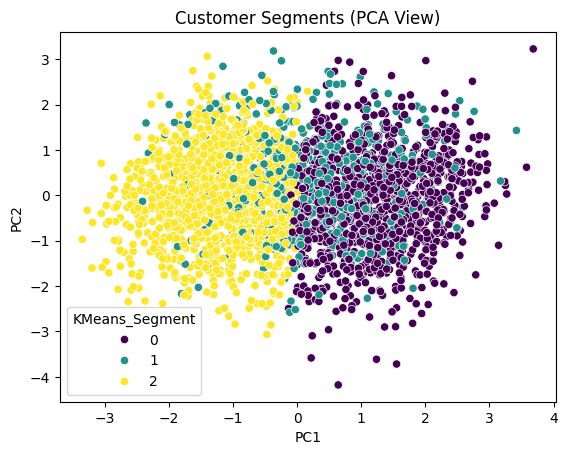

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_seg_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}\n")

# PCA Scatter Plot
sns.scatterplot(x='PC1', y='PC2', hue='KMeans_Segment', palette='viridis', data=df)
plt.title("Customer Segments (PCA View)")
plt.show()

# Isolation Forest for Anomalies
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df['Anomaly_Flag'] = iso_forest.fit_predict(X_seg_scaled)
df['Anomaly_Flag'] = df['Anomaly_Flag'].map({1: 0, -1: 1})

## ***Customer 360 Integration***

In [ ]:
# Repredict for the entire dataset
df_full_prepped_c = df.drop(columns=['Churn', 'Future12MRevenueEGP', 'KMeans_Segment', 'DBSCAN_Labels', 'PC1', 'PC2', 'Anomaly_Flag'], errors='ignore')
df_full_prepped_r = df.drop(columns=['Future12MRevenueEGP', 'KMeans_Segment', 'DBSCAN_Labels', 'PC1', 'PC2', 'Anomaly_Flag'], errors='ignore')

# We need the original CustomerID back for the final table.
# Assuming we load it again just for the final export:
df_orig = pd.read_csv("customer_360_ml_workshop.csv")

final_360 = pd.DataFrame()
final_360['CustomerID'] = df_orig['CustomerID']
final_360['Churn_Probability'] = best_rf.predict_proba(df_full_prepped_c)[:, 1]
final_360['Predicted_12M_Revenue'] = best_reg_model.predict(df_full_prepped_r)
final_360['Customer_Segment'] = df['KMeans_Segment']
final_360['Anomaly_Flag'] = df['Anomaly_Flag']

# Retention Priority Rule: High churn risk (>0.5) AND High predicted future revenue (above median)
median_predicted_rev = final_360['Predicted_12M_Revenue'].median()
final_360['Retention_Priority'] = np.where(
    (final_360['Churn_Probability'] > 0.5) & (final_360['Predicted_12M_Revenue'] > median_predicted_rev),
    'High Priority', 'Standard/Low Priority'
)

In [ ]:
# Save to CSV
import os
os.makedirs("outputs", exist_ok=True)
final_360.to_csv("outputs/customer_360_predictions.csv", index=False)
print("Customer 360 file saved to outputs/customer_360_predictions.csv")

Customer 360 file saved to outputs/customer_360_predictions.csv
